[*********************100%***********************]  13 of 13 completed


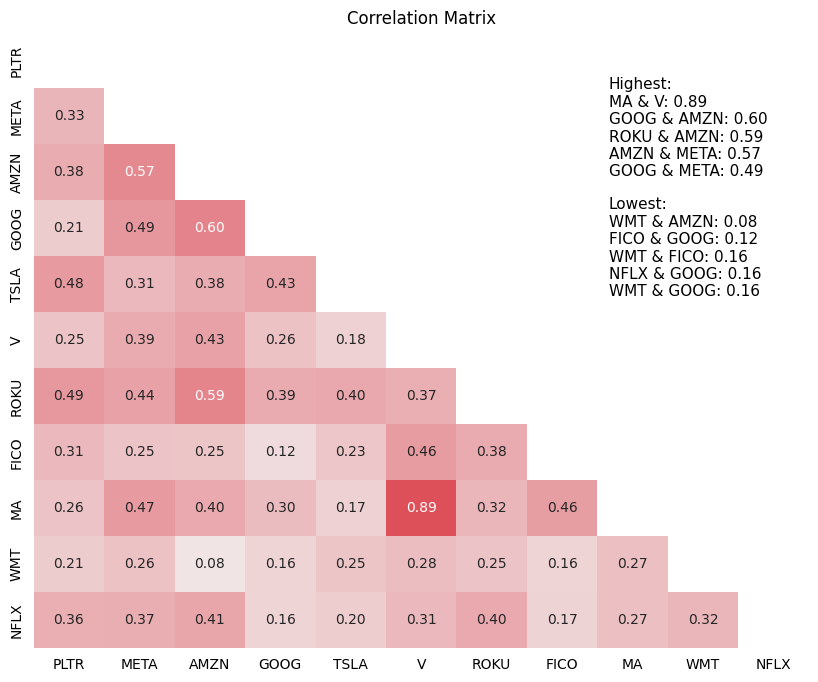

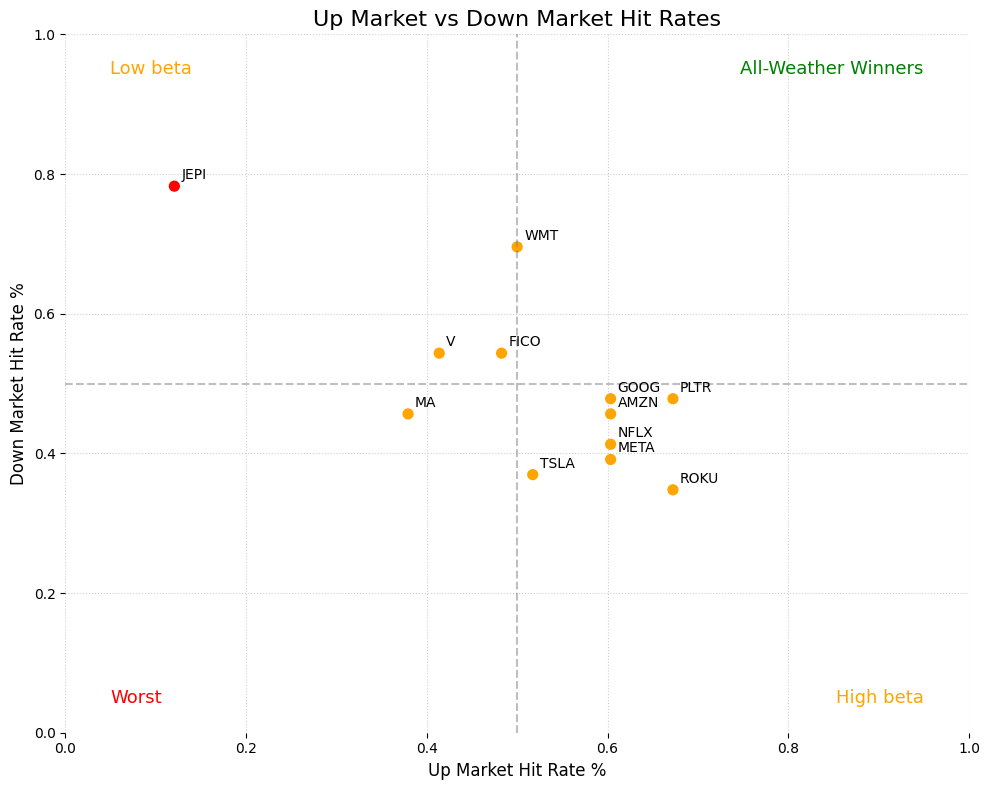

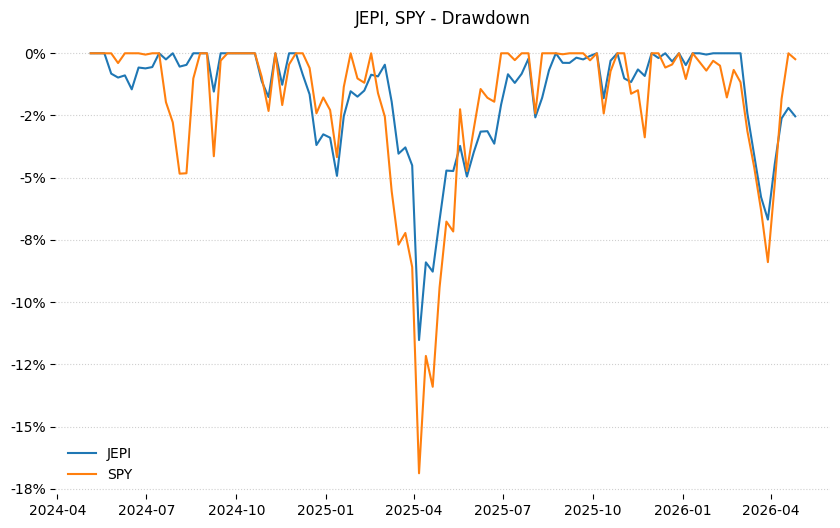

,Hit Rate,Up Market Hit Rate,Down Market Hit Rate,Beta,Up Market Beta,Down Market Beta,Up Capture Ratio,Down Capture Ratio,Max Drawdown,Recuperation Ratio
PLTR,0.586538,0.672414,0.478261,2.096724,2.803176,1.601805,2.810828,0.919783,-0.378902,9.731553
META,0.509615,0.603448,0.391304,1.490875,1.623504,1.152894,1.528154,1.607375,-0.328917,1.745068
AMZN,0.538462,0.603448,0.456522,1.464469,1.577245,1.077367,1.484733,1.665568,-0.280545,1.527974
GOOG,0.548077,0.603448,0.478261,1.139921,1.249605,0.487391,1.480129,1.173571,-0.280602,2.305221
TSLA,0.451923,0.517241,0.369565,1.775318,2.574591,1.270577,1.875356,1.288583,-0.451138,2.856295
V,0.471154,0.413793,0.543478,0.781367,0.929361,0.642689,0.704746,0.851044,-0.197131,1.437260
ROKU,0.528846,0.672414,0.347826,2.313356,1.862713,2.717566,2.419203,2.277918,-0.442011,2.186489
FICO,0.509615,0.482759,0.543478,1.366054,1.242309,1.016889,1.298565,1.882475,-0.611639,2.574921
MA,0.413462,0.379310,0.456522,0.795868,0.754126,0.629565,0.770731,1.015693,-0.189249,1.374793
WMT,0.586538,0.500000,0.695652,0.634806,1.019565,0.659309,0.832550,-0.023285,-0.198208,2.278962


In [ ]:
# This project includes correlation matrix, hit rate analysis, beta analysis, capture ratio analysis, and drawdown 
# analysis for a selected fund and its holdings compared to a benchmark. The code retrieves historical price data, 
# calculates returns, and visualizes the results using heatmaps and scatter plots.
# To be added: rolling pairwise correlation for the fund holdings. Asset class return time series. 



import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from datetime import date, timedelta

# Fund holdings, fund and benchmark prices. 
# Placeholder tickers, replace with actual holdings or index constituents and benchmark as needed.
selected_fund_holdings = ['PLTR', 'META', 'AMZN', 'GOOG', 'TSLA', 'V', 'ROKU', 'FICO', 'MA', 'WMT', 'NFLX']
selected_fund = ['JEPI']
selected_benchmark = ['SPY']
# other option for funds: 'IGM' whose full name is iShares Expanded Tech Sector ETF
# other option for benchmark: ['QQQ', 'IWM', 'VTI', 'ACWI']

# Select the start and end dates
start_date = (date.today() - timedelta(days=2*365)).strftime("%Y-%m-%d")
end_date = date.today().strftime("%Y-%m-%d")

# Retrieve the prices, resample to weekly
tickers = selected_fund_holdings + selected_fund + selected_benchmark
df_prices = yf.download(tickers, start=start_date, end=end_date)['Close']
df_prices = df_prices.resample('W').last()

# Convert to returns
df_returns = df_prices.pct_change().dropna()

### Correlation Matrix ###
def cor_matrix(tickers_list):
    # Compute correlation matrix
    correlation_matrix = df_returns.loc[:,tickers_list].corr(method='pearson', min_periods=10)

    # Mask the upper triangle
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    # Plot the heatmap
    #plt.style.use("dark_background")
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, 
                mask=mask, 
                annot=True, 
                fmt=".2f", 
                #cmap='coolwarm',
                cmap = sns.diverging_palette(133, 10, as_cmap=True),
                vmin=-1, 
                vmax=1, 
                cbar=False, 
                cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix')
    plt.xlabel('')
    plt.ylabel('')
    plt.grid(False)
    plt.tick_params(
        axis='both',
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,
        left=False,        # ticks along the top edge are off
        labelbottom=True,
        labelleft=True)    # labels along the bottom edge are shown

    # Extract top 5 and bottom 5 correlation pairs
    correlation_pairs = correlation_matrix.where(~mask).stack().dropna().sort_values(kind="quicksort")
    # Exclude self correlations
    filtered_correlation_pairs = correlation_pairs[correlation_pairs != 1].dropna()
    top_5_pairs = filtered_correlation_pairs[-5:][::-1]
    bottom_5_pairs = filtered_correlation_pairs[:5]#[::-1]

    # Create legend text for top 5 and bottom 5 pairs
    top_5_text = "\n".join([f"{idx[0]} & {idx[1]}: {corr:.2f}" for idx, corr in top_5_pairs.items()])
    bottom_5_text = "\n".join([f"{idx[0]} & {idx[1]}: {corr:.2f}" for idx, corr in bottom_5_pairs.items()])

    # Add the legend to the plot
    plt.figtext(0.7, 0.7, f"Highest:\n{top_5_text}", horizontalalignment='left', fontsize=11, bbox={"facecolor":"white", "alpha":0.5, "pad":5, "edgecolor": "none"})
    plt.figtext(0.7, 0.55, f"Lowest:\n{bottom_5_text}", horizontalalignment='left', fontsize=11, bbox={"facecolor":"white", "alpha":0.5, "pad":5, "edgecolor": "none"})
    
    plt.show()
    
#cor_matrix(tickers)
cor_matrix(selected_fund_holdings)

# Separate the benchmark from the other stocks
benchmark = selected_benchmark[0]

# Initialize result dictionaries (outside the loop)
results = {
    'Hit Rate': {}, 'Up Market Hit Rate': {}, 'Down Market Hit Rate': {},
    'Beta': {}, 'Up Market Beta': {}, 'Down Market Beta': {},
    'Up Capture Ratio': {}, 'Down Capture Ratio': {},
    'Max Drawdown': {}, 'Recuperation Ratio': {}
}
drawdown_series = {}  # New dictionary to store drawdown time series for each stock

# Loop through each stock for hit rate, beta, and drawdown analysis
for stock in tickers:
    # 1. Prepare stock-specific data
    stock_returns = df_returns[stock]
    benchmark_returns = df_returns[benchmark]
        
    # Skip beta, hit rate and capture ratio calculations for the benchmark
    if stock != benchmark:
        # 2. Calculate hit rates
        results['Hit Rate'][stock] = (stock_returns > benchmark_returns).mean()
        
        up_market = df_returns[df_returns[benchmark] > 0]
        down_market = df_returns[df_returns[benchmark] <= 0]
        
        results['Up Market Hit Rate'][stock] = (up_market[stock] > up_market[benchmark]).mean() if len(up_market) > 0 else 0
        results['Down Market Hit Rate'][stock] = (down_market[stock] > down_market[benchmark]).mean() if len(down_market) > 0 else 0
            
        # 3. Calculate betas
        cov_matrix = df_returns[[stock, benchmark]].cov()
        results['Beta'][stock] = cov_matrix.loc[stock, benchmark] / df_returns[benchmark].var()

        up_market_beta = up_market[[stock, benchmark]].cov().loc[stock, benchmark] / up_market[benchmark].var() if len(up_market) > 0 else 0
        down_market_beta = down_market[[stock, benchmark]].cov().loc[stock, benchmark] / down_market[benchmark].var() if len(down_market) > 0 else 0

        results['Up Market Beta'][stock] = up_market_beta
        results['Down Market Beta'][stock] = down_market_beta
    
        # 4. Calculate capture ratios
        results['Up Capture Ratio'][stock] = (up_market[stock].mean() / up_market[benchmark].mean()) if up_market[benchmark].mean() != 0 else 0
        results['Down Capture Ratio'][stock] = (down_market[stock].mean() / down_market[benchmark].mean()) if down_market[benchmark].mean() != 0 else 0
        
    # 5. Calculate drawdown metrics
    cum_returns = (1 + stock_returns).cumprod()
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns / rolling_max) - 1
    
    drawdown_series[stock] = drawdown  # Store the full drawdown series for later plotting
    
    results['Max Drawdown'][stock] = drawdown.min()
    results['Recuperation Ratio'][stock] = cum_returns.max() / cum_returns.min()

# After the loop, convert results to DataFrame
results_df = pd.DataFrame(results)


### Scatter Plot for Hit Rates ###
# Change the color of the marker for the selected_fund
colors = ['red' if stock in selected_fund else 'orange' for stock in tickers]
#plt.style.use("dark_background")
plt.figure(figsize=(10, 8))
plt.scatter(results_df['Up Market Hit Rate'], results_df['Down Market Hit Rate'], s=50, color=colors)

# Add labels for each point 
for i, stock in enumerate(tickers):
    plt.annotate(stock, (results_df['Up Market Hit Rate'].iloc[i], results_df['Down Market Hit Rate'].iloc[i]), 
                 xytext=(5, 5), textcoords='offset points')

# Set the plot title and labels
plt.title('Up Market vs Down Market Hit Rates', fontsize=16)
plt.xlabel('Up Market Hit Rate %', fontsize=12)
plt.ylabel('Down Market Hit Rate %', fontsize=12)

# Set the axes to start from 0 and end at 1
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add quadrant lines and labels
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.text(0.05, 0.95, 'Low beta', horizontalalignment='left', verticalalignment='center', color='orange', fontsize=13)
plt.text(0.95, 0.95, 'All-Weather Winners', horizontalalignment='right', verticalalignment='center', color='green', fontsize=13)
plt.text(0.05, 0.05, 'Worst', horizontalalignment='left', verticalalignment='center', color='red', fontsize=13)
plt.text(0.95, 0.05, 'High beta', horizontalalignment='right', verticalalignment='center', color='orange', fontsize=13)

# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Add a light grid
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


""" Drawdown Analysis """
def percentage_formatter(x, pos):
    return f'{100 * x:.0f}%'

plt.figure(figsize=(10, 6))

for ticker in selected_fund + selected_benchmark:
    plt.plot(drawdown_series[ticker].index, drawdown_series[ticker], label=f'{ticker}')

tickers_string = ", ".join(selected_fund + selected_benchmark)
plot_title = tickers_string + " - Drawdown"

plt.title(plot_title)
plt.xlabel('')
plt.ylabel('')
plt.legend(loc='best', frameon=False)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(percentage_formatter))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.show()

results_df